# County-Level OHCA GWR with SVI Risk Factors (Georgia)

This notebook estimates spatially varying associations between county OHCA case counts and selected Social Vulnerability Index (SVI) variables using **Geographically Weighted Regression (GWR)**.

## Risk factors used
- `EP_AGE65`:% aged 65 and older. Older adults have much higher cardiac arrest risk.
- `EP_DISABL`:% civilian population with disability. Captures health vulnerability and chronic disease burden indirectly.
- `EP_UNINSUR`:% uninsured. Related to poorer healthcare access and delayed treatment/prevention.
- `EP_POV150`: % below 150% poverty. Poverty is strongly related to health risk, chronic disease, and emergency outcomes
- `EP_NOHSDP`:% age 25+ with no high school diploma. Education reflects socioeconomic status and health literacy.
- `EP_UNEMP`: Unemployment rate. Captures economic disadvantage and neighborhood-level health vulnerability.
- `EP_NOVEH`: % households with no vehicle. Related to healthcare access, EMS dependence, and transportation disadvantage.
- `EP_MINRTY`:% racial/ethnic minority population. Important for capturing structural inequities and spatial disparities in OHCA risk.

## 1. Install Packages

In [1]:
# Install geospatial modeling dependencies for GWR analysis.
!pip -q install geopandas mgwr matplotlib mapclassify

In [2]:
# Mount Google Drive to load source data and save outputs.
from google.colab import drive
# Mount Google Drive so the notebook can read and write workshop files.
drive.mount('/content/drive/')

Mounted at /content/drive/


## 2. Imports and Paths

In [4]:
# Import Path so file and folder locations can be built with the / operator.
from pathlib import Path
# Import NumPy for numerical arrays and calculations used in the model.
import numpy as np
# Import pandas to read CSV files and work with tabular data.
import pandas as pd
# Import GeoPandas to read shapefiles and handle county geometry.
import geopandas as gpd
# Import pyplot to create maps, charts, and other figures.
import matplotlib.pyplot as plt

# Import Sel_BW to choose the GWR bandwidth for the county-level model.
from mgwr.sel_bw import Sel_BW
# Import GWR to fit geographically weighted regression models.
from mgwr.gwr import GWR

# Store the local Workshop folder path for running this notebook on this computer.
LOCAL_ROOT = Path('/Users/jenny/Desktop/Using-Python-for-Geospatial-Analysis-and-Visualization-main/')
# Store the Google Colab Workshop folder path for running this notebook in Colab.
COLAB_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/')
# Use the Colab folder if it exists; otherwise use the local Workshop folder.
ROOT = COLAB_ROOT if COLAB_ROOT.exists() else LOCAL_ROOT

# Point to the data folder inside the selected Workshop root folder.
DATA_DIR = ROOT/'data'

# Build the path to the OHCA case data CSV file.
OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
# Build the path to the county boundary shapefile.
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'
# Build the path to the county Social Vulnerability Index CSV file.
SVI_CSV = ROOT/'data'/'svi_GA_county.csv'


# Print the OHCA CSV path so the user can confirm the notebook found the right file.
print('OHCA:', OHCA_CSV)
# Print the county shapefile path so the user can confirm the notebook found the right file.
print('County shapefile:', COUNTY_SHP)
# Print the SVI CSV path so the user can confirm the notebook found the right file.
print('SVI:', SVI_CSV)


OHCA: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/ohca_connected_data.csv
County shapefile: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp
SVI: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/svi_GA_county.csv


## 3. Build County OHCA Case Counts

In [5]:

# Define the latitude column in the OHCA dataset.
lat_col = 'scene_gps_latitude_escene.11'

# Define the longitude column in the OHCA dataset.
lon_col = 'scene_gps_longitude_escene.11'

# Load the OHCA event records from the CSV file.
ohca = pd.read_csv(OHCA_CSV)

# Convert latitude values to numeric format, setting invalid values to missing.
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')

# Convert longitude values to numeric format, setting invalid values to missing.
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')

# Remove records that do not have usable latitude and longitude values.
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

# Create a GeoDataFrame of OHCA events using longitude latitude point geometry and geospatial reference system.
ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

# Load county boundary polygons and convert them to the same coordinate system as the OHCA points.
counties = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')

# Keep only Georgia counties and the columns needed for county-level analysis.
ga_counties = counties[counties['STATEFP'].astype(str) == '13'][['GEOID', 'NAME', 'geometry']].copy()

# Spatially join each OHCA point to the Georgia county polygon that contains it.
joined = gpd.sjoin(
    ohca_points,
    ga_counties,
    how='inner',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Count the number of OHCA cases assigned to each Georgia county.
ohca_county = (
    joined.groupby(['GEOID', 'NAME'])
    .size()
    .rename('ohca_cases')
    .reset_index()
)

# Add the county-level OHCA case counts back to the Georgia county polygons.
ga_counties = ga_counties.merge(ohca_county, on=['GEOID', 'NAME'], how='left')

# Replace counties with no assigned OHCA cases with zero and store counts as integers.
ga_counties['ohca_cases'] = ga_counties['ohca_cases'].fillna(0).astype(int)

# Print the number of Georgia counties included in the analysis.
print('Georgia counties:', len(ga_counties))

# Print the total number of OHCA cases successfully assigned to counties.
print('Total OHCA cases assigned:', ga_counties['ohca_cases'].sum())

# Preview county identifiers, names, and OHCA case counts.
ga_counties[['GEOID', 'NAME', 'ohca_cases']].head()

Georgia counties: 159
Total OHCA cases assigned: 5963


,GEOID,NAME,ohca_cases
0,13009,Baldwin,0
1,13027,Brooks,2
2,13103,Effingham,3
3,13121,Fulton,232
4,13141,Hancock,0


## 4. Load SVI and Keep Requested Variables

In [6]:
# Select SVI predictor variables to include in the GWR model.
svi_vars = [
    'EP_AGE65',
    'EP_DISABL',
    'EP_UNINSUR',
    'EP_POV150',
    'EP_NOHSDP',
    'EP_UNEMP',
    'EP_NOVEH',
    'EP_MINRTY'
]

# Read the CSV data into a pandas DataFrame.
svi = pd.read_csv(SVI_CSV)

# County key in provided CSV is FIPS; ensure 5-digit string.
svi['GEOID'] = svi['FIPS'].astype(str).str.zfill(5)

# Define needed_cols for the next part of the analysis.
needed_cols = ['GEOID', 'COUNTY'] + svi_vars
# Define missing for the next part of the analysis.
missing = [c for c in needed_cols if c not in svi.columns]
# Check whether this condition is true before continuing.
if missing:
    # Stop if any required SVI predictor fields are missing.
    raise ValueError(f'Missing required SVI columns: {missing}')

# Define svi_sub for the next part of the analysis.
svi_sub = svi[needed_cols].copy()
# Loop through these values to repeat the same analysis step.
for c in svi_vars:
    # Convert this column to numeric values and mark invalid entries as missing.
    svi_sub[c] = pd.to_numeric(svi_sub[c], errors='coerce')

# Print this value to check the analysis result.
print('SVI rows:', len(svi_sub))
# Preview the first rows of the result.
svi_sub.head()

SVI rows: 159


,GEOID,COUNTY,EP_AGE65,EP_DISABL,EP_UNINSUR,EP_POV150,EP_NOHSDP,EP_UNEMP,EP_NOVEH,EP_MINRTY
0,13001,Appling,17.2,15.1,12.3,37.3,22.8,3.8,8.2,31.1
1,13003,Atkinson,12.9,15.3,20.9,44.9,32.3,6.4,5.0,44.2
2,13005,Bacon,15.6,19.2,19.1,39.3,17.6,4.3,7.7,26.8
3,13007,Baker,29.8,19.6,13.6,39.2,16.8,14.0,7.6,49.9
4,13009,Baldwin,15.9,16.5,11.7,31.9,13.5,7.4,6.3,47.8


## 5. Merge OHCA Counts + SVI at County Level

In [7]:
# Merge county outcomes with SVI predictors to build the modeling dataset.
gwr_gdf = ga_counties.merge(svi_sub, on='GEOID', how='left')

# Keep rows with complete SVI values
gwr_gdf = gwr_gdf.dropna(subset=svi_vars).copy()

# Print this value to check the analysis result.
print('Counties with complete SVI + OHCA:', len(gwr_gdf))
# Preview the first rows of the result.
gwr_gdf[['GEOID', 'NAME', 'ohca_cases'] + svi_vars[:3]].head()

Counties with complete SVI + OHCA: 159


,GEOID,NAME,ohca_cases,EP_AGE65,EP_DISABL,EP_UNINSUR
0,13009,Baldwin,0,15.9,16.5,11.7
1,13027,Brooks,2,19.1,14.7,15.4
2,13103,Effingham,3,11.7,10.7,9.3
3,13121,Fulton,232,11.7,10.0,10.1
4,13141,Hancock,0,22.9,16.1,12.6


## 6. Prepare Inputs for GWR

We use county centroids as coordinate locations and standardize predictors for comparability.

Dependent variable:
- `log1p(ohca_cases)` for more stable Gaussian GWR fitting.

In [8]:
# Project county polygons to EPSG:3857 so distances are measured in meters for GWR.
gwr_3857 = gwr_gdf.to_crs('EPSG:3857').copy()

# Calculate the centroid of each county polygon to use as the county's model location.
cent = gwr_3857.geometry.centroid

# Combine centroid x and y coordinates into the coordinate matrix required by GWR.
coords = np.column_stack([cent.x.values, cent.y.values])

# Create the response variable as log-transformed OHCA case counts with shape n x 1.
y = np.log1p(gwr_3857['ohca_cases'].values).reshape((-1, 1))

# Extract the selected SVI predictor columns as numeric model inputs.
X_raw = gwr_3857[svi_vars].values.astype(float)

# Calculate the mean of each predictor for standardization.
X_mean = X_raw.mean(axis=0)

# Calculate the standard deviation of each predictor for standardization.
X_std = X_raw.std(axis=0)

# Standardize predictors so variables are on comparable scales for GWR.
X = (X_raw - X_mean) / X_std

# Print the coordinate matrix shape to confirm it matches the number of counties.
print('coords shape:', coords.shape)

# Print the response variable shape to confirm it is formatted as n x 1.
print('y shape:', y.shape)

# Print the predictor matrix shape to confirm rows and predictor columns are correct.
print('X shape:', X.shape)

coords shape: (159, 2)
y shape: (159, 1)
X shape: (159, 8)


## 7. Select Bandwidth and Fit GWR

In [9]:
# Use adaptive bandwidth so each local regression uses a similar number of nearby counties.
bw_selector = Sel_BW(coords, y, X, fixed=False)

# Search for the bandwidth value that best fits the GWR model.
bw = bw_selector.search()

# Print the selected adaptive bandwidth for review.
print('Optimal adaptive bandwidth:', bw)

# Build the GWR model using county coordinates, response values, predictors, and selected bandwidth.
gwr_model = GWR(coords, y, X, bw, fixed=False)

# Fit the GWR model and store the results.
gwr_results = gwr_model.fit()

# Print the model summary, including fit statistics and coefficient information.
print(gwr_results.summary())

Optimal adaptive bandwidth: 81.0
Model type                                                         Gaussian
Number of observations:                                                 159
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            317.976
Log-likelihood:                                                    -280.710
AIC:                                                                579.421
AICc:                                                               582.907
BIC:                                                               -442.360
R2:                                                                   0.377
Adj. R2:                                                              0.343

Variable                              Est.         SE  t(Est/SE)    p-value
---------------------------

## 8. Save Local Coefficients and Diagnostics

In [10]:
# Extract the local intercept for each county from the first column of the GWR results.
gwr_3857['gwr_intercept'] = gwr_results.params[:, 0]

# Extract each local SVI predictor coefficient and save it as a new county-level column.
for idx, v in enumerate(svi_vars, start=1):
    # Store local GWR coefficient estimates in the county GeoDataFrame.
    gwr_3857[f'gwr_b_{v}'] = gwr_results.params[:, idx]

# Add the local R-squared value, which shows model fit separately for each county.
gwr_3857['gwr_local_R2'] = gwr_results.localR2

# Extract filtered local t-values for each SVI predictor to help identify stronger local effects.
for idx, v in enumerate(svi_vars, start=1):
    # Store filtered local t-values for predictor interpretation.
    gwr_3857[f'gwr_t_{v}'] = gwr_results.filter_tvals()[:, idx]

# Preview county names, local model fit, and the first few local coefficient columns.
gwr_3857[['NAME', 'gwr_local_R2'] + [f'gwr_b_{v}' for v in svi_vars[:3]]].head()

,NAME,gwr_local_R2,gwr_b_EP_AGE65,gwr_b_EP_DISABL,gwr_b_EP_UNINSUR
0,Baldwin,0.669711,-0.937721,-0.655353,0.641908
1,Brooks,0.389015,-0.276682,-0.400953,-0.079230
2,Effingham,0.517399,-0.159489,-0.258577,0.416774
3,Fulton,0.738722,-0.472904,0.275598,-0.051513
4,Hancock,0.673560,-0.947067,-0.679652,0.627798


## 9. Map Local Coefficients (Example)

Below we map local coefficients for one variable; repeat for others as needed.

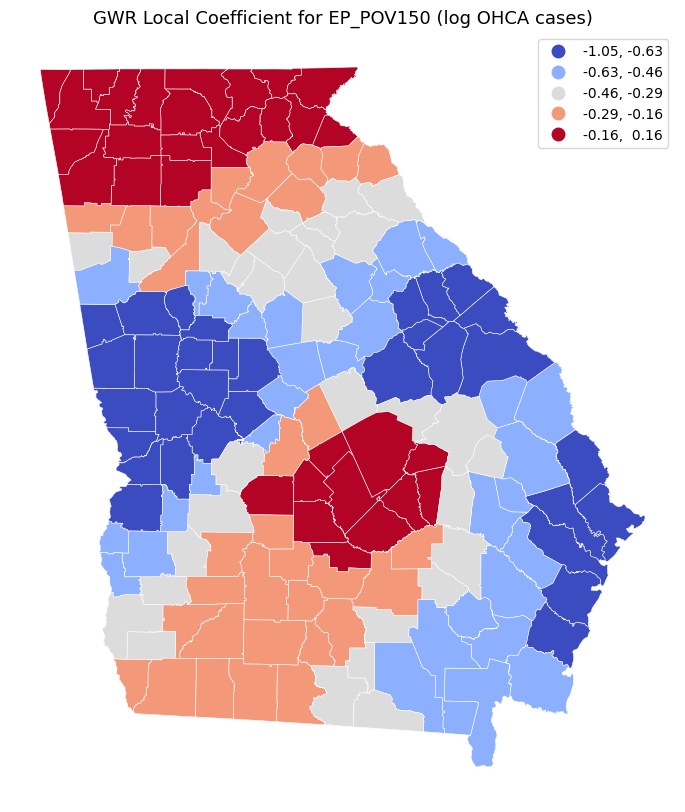

In [11]:
# Choose which local GWR coefficient to visualize on the map.
map_var = 'EP_POV150'  # change to any variable in svi_vars

# Build the name of the coefficient column created from the selected SVI variable.
coef_col = f'gwr_b_{map_var}'

# Reproject the GWR results back to latitude/longitude coordinates for mapping.
gwr_plot = gwr_3857.to_crs('EPSG:4326')

# Create the map figure and axis.
fig, ax = plt.subplots(figsize=(10, 10))

# Plot counties colored by the selected local GWR coefficient value.
gwr_plot.plot(
    column=coef_col,
    cmap='coolwarm',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)

# Add a title that identifies the mapped coefficient and outcome scale.
ax.set_title(f'GWR Local Coefficient for {map_var} (log OHCA cases)', fontsize=13)

# Remove axis ticks and labels for a cleaner map.
ax.axis('off')

# Display the completed coefficient map.
plt.show()

## 10. Map Local R2

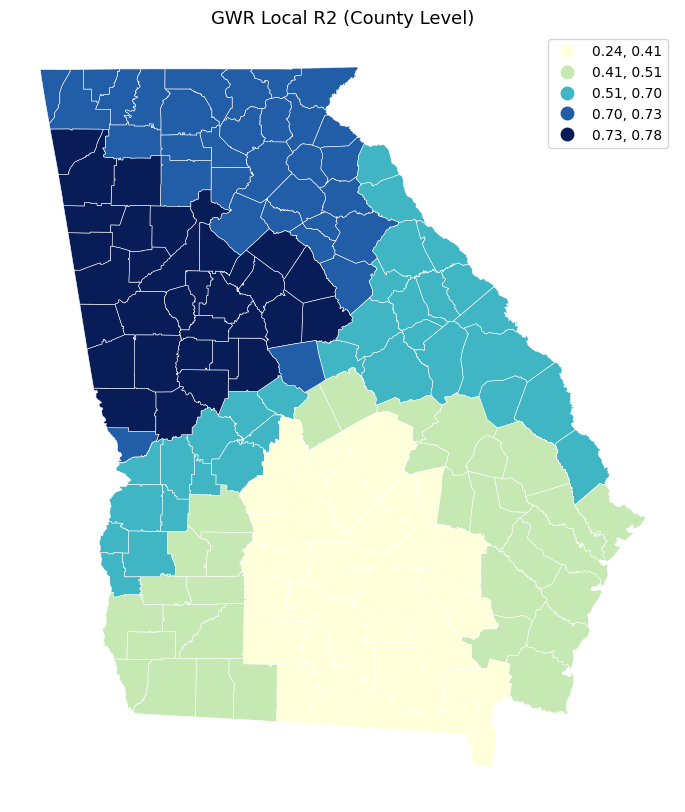

In [12]:
# Reproject GWR results back to WGS84 for web-friendly visualization.
gwr_plot = gwr_3857.to_crs('EPSG:4326')

# Create the map figure and axis for the local R-squared map.
fig, ax = plt.subplots(figsize=(10, 10))

# Plot counties by local R-squared to show where the GWR model fits better or worse.
gwr_plot.plot(
    column='gwr_local_R2',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)

# Add a title describing the mapped local model fit statistic.
ax.set_title('GWR Local R2 (County Level)', fontsize=13)

# Remove axis ticks and labels for a cleaner map.
ax.axis('off')

# Display the completed local R-squared map.
plt.show()

## 11. Export Results

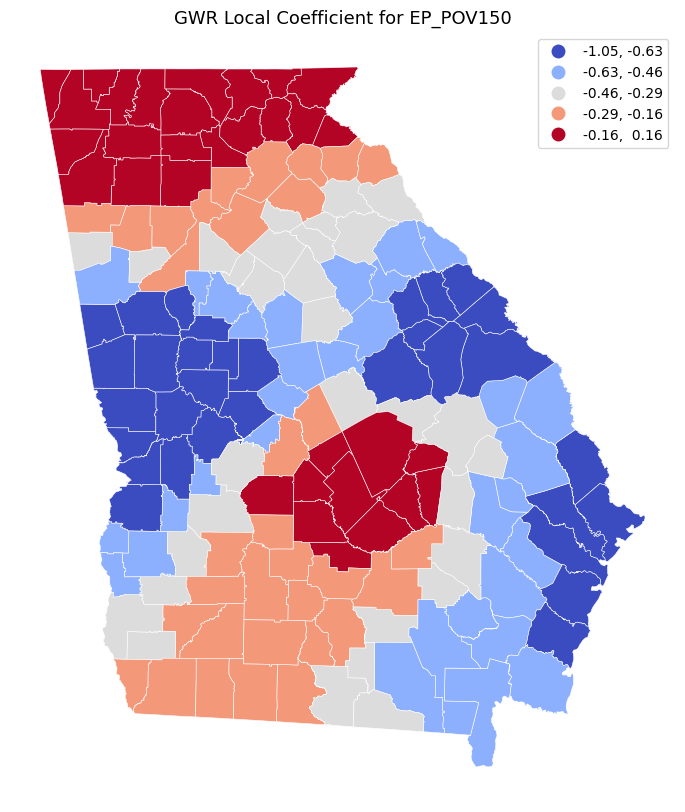

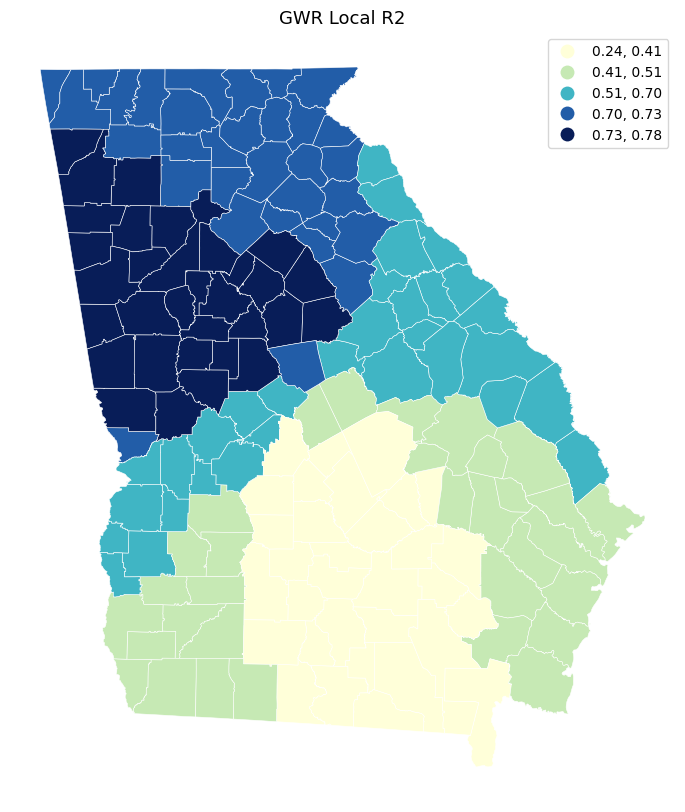

Saved CSV: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_ohca_gwr_svi_results.csv
Saved GeoJSON: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_ohca_gwr_svi_results.geojson
Saved coefficient map PNG: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/gwr_coef_EP_POV150_map.png
Saved local R2 map PNG: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/gwr_local_R2_map.png


In [13]:
# Set and create the output folder for GWR maps and coefficient tables.
OUTPUT_DIR = DATA_DIR / 'outputs'
# Create the output folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)

# Define csv_out for the next part of the analysis.
csv_out = OUTPUT_DIR / 'county_ohca_gwr_svi_results.csv'
# Define geojson_out for the next part of the analysis.
geojson_out = OUTPUT_DIR / 'county_ohca_gwr_svi_results.geojson'
# Define the output path for the accessibility map image.
coef_map_png = OUTPUT_DIR / 'gwr_coef_EP_POV150_map.png'
# Define the output path for the accessibility map image.
r2_map_png = OUTPUT_DIR / 'gwr_local_R2_map.png'

# Reproject the spatial data to the coordinate system needed for this step.
gwr_out = gwr_3857.to_crs('EPSG:4326').copy()
# Save the table results to a CSV file.
gwr_out.drop(columns='geometry').to_csv(csv_out, index=False)
# Save the spatial results to a GeoJSON or GIS file.
gwr_out.to_file(geojson_out, driver='GeoJSON')

# Save coefficient map
fig, ax = plt.subplots(figsize=(10, 10))
# Draw the map or chart for this analysis output.
gwr_out.plot(
    column='gwr_b_EP_POV150',
    cmap='coolwarm',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
# Adjust the plot appearance.
ax.set_title('GWR Local Coefficient for EP_POV150', fontsize=13)
# Hide map axes for a cleaner display.
ax.axis('off')
# Save the current figure as an image file.
fig.savefig(coef_map_png, dpi=300, bbox_inches='tight')
# Show the completed plot.
plt.show()

# Save local R2 map
fig, ax = plt.subplots(figsize=(10, 10))
# Draw the map or chart for this analysis output.
gwr_out.plot(
    column='gwr_local_R2',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
# Adjust the plot appearance.
ax.set_title('GWR Local R2', fontsize=13)
# Hide map axes for a cleaner display.
ax.axis('off')
# Save the current figure as an image file.
fig.savefig(r2_map_png, dpi=300, bbox_inches='tight')
# Show the completed plot.
plt.show()

# Print this value to check the analysis result.
print('Saved CSV:', csv_out)
# Print this value to check the analysis result.
print('Saved GeoJSON:', geojson_out)
# Print this value to check the analysis result.
print('Saved coefficient map PNG:', coef_map_png)
# Print this value to check the analysis result.
print('Saved local R2 map PNG:', r2_map_png)

## Notes for Interpretation

- A positive local coefficient means higher predictor values are locally associated with higher log OHCA case counts.
- Coefficients can vary across counties; that is the key value of GWR.
- Compare local coefficient maps and local R2 to identify where model relationships are strongest.
- For inference-focused work, also consider count models, population offsets/rates, and multicollinearity diagnostics.